In [12]:
####################################
# consolidated imports
####################################
# We use character-level sequence-to-sequence modeling. This requires robust
# linear algebra (torch) and data manipulation (pandas) libraries.
from __future__ import annotations

import math
import random
import time
from datetime import datetime
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# Ensure plot styling is consistent for academic reporting
plt.style.use("seaborn-v0_8-whitegrid")

In [13]:
####################################
# GLOBAL CONFIGURATION & HYPERPARAMETERS
# All user-manipulated variables are defined here for easy tuning.
####################################
import torch
from pathlib import Path

# ==========================================
# 1. FILE & DIRECTORY PATHS
# ==========================================
# Name of the cleaned dataset file. Expected columns: 'arabic_stripped', 'arabic_harakat'
CLEANED_FILE_NAME = "maknuune-v1.0.1_cleaned.csv"

try:
    from google.colab import drive
    drive.mount("/content/drive")
    ARABIZI_DIR = Path("/content/drive/MyDrive/arabizi")
except ModuleNotFoundError:
    ARABIZI_DIR = Path.cwd() / "working_files" / "data"

PROJECT_DIR = ARABIZI_DIR
WORKING_DIR = ARABIZI_DIR
DATA_FILE = ARABIZI_DIR / CLEANED_FILE_NAME
RESULTS_DIR = ARABIZI_DIR
METRICS_FILE = RESULTS_DIR / "harakat_adder_metrics.csv"
PROGRESS_FILE = RESULTS_DIR / "harakat_adder_progress.csv"
CHECKPOINT_FILE = RESULTS_DIR / "harakat_adder_checkpoint.pt"
MODEL_FILE = RESULTS_DIR / "harkat_adder.pt"
MODEL_DIR = MODEL_FILE.parent

# ==========================================
# 2. DATASET SPLITS & SEED
# ==========================================
SEED = 42                # Seed for reproducibility across runs
TRAIN_FRACTION = 0.80    # 80% of data for training
VAL_FRACTION = 0.10      # 10% for validation (tuning during training)
TEST_FRACTION = 0.10     # 10% for final testing

# ==========================================
# 3. TRAINING HYPERPARAMETERS
# ==========================================
BATCH_SIZE = 128         # Number of sequences per batch. Balance between speed and memory.
EPOCHS = 100             # Maximum number of full passes through the training data.
LEARNING_RATE = 3e-4     # Max learning rate for the scheduler. 3e-4 is stable for Transformers.
WEIGHT_DECAY = 1e-4      # L2 regularization to prevent overfitting.
GRAD_CLIP_NORM = 1.0     # Clips gradients to prevent 'exploding gradients'.
PATIENCE = 10            # Early stopping: stop if validation loss doesn't improve for 10 epochs.

# ==========================================
# 4. TRANSFORMER MODEL ARCHITECTURE
# ==========================================
D_MODEL = 192            # Dimensionality of the embeddings and hidden states.
NHEAD = 6                # Number of attention heads (D_MODEL must be divisible by NHEAD).
NUM_ENCODER_LAYERS = 4   # Number of Transformer encoder blocks.
NUM_DECODER_LAYERS = 4   # Number of Transformer decoder blocks.
DIM_FEEDFORWARD = 768    # Hidden layer size in the feedforward network (usually 4x D_MODEL).
DROPOUT = 0.15           # Dropout probability for regularization.
MAX_LEN_BUFFER = 8       # Extra padding added to the maximum sequence length found in the data.

# ==========================================
# 5. INFERENCE & EVALUATION SETTINGS
# ==========================================
BEAM_WIDTH = 5           # Number of paths to keep during beam search decoding.
BEAM_THRESHOLD = 0.90    # Cumulative probability threshold for nucleus/threshold beam search.
NUM_EVAL_SAMPLES = 100    # Number of samples to use during slow beam search evaluations.

# ==========================================
# 6. OPERATIONAL & DEBUG FLAGS
# ==========================================
FRESH_START = True       # If True, deletes old checkpoints and starts from scratch.
QUICK_RUN_ROWS = None    # If int (e.g., 1000), limits dataset size for quick testing. Set to None for full run.
DRY_RUN = False          # If True, runs a single batch and exits to verify shapes/memory.
PROGRESS_EVERY_N_BATCHES = 25 # How often to log progress.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 7. SPECIAL TOKENS
# ==========================================
PAD = "<PAD>"            # Padding token for shorter sequences in a batch.
BOS = "<BOS>"            # Beginning of Sequence token.
EOS = "<EOS>"            # End of Sequence token.
UNK = "<UNK>"            # Unknown character token.
SPECIAL_TOKENS = [PAD, BOS, EOS, UNK]

print("Device:", DEVICE)
print("Data file:", DATA_FILE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Data file: /content/drive/MyDrive/arabizi/maknuune-v1.0.1_cleaned.csv


In [14]:
####################################
# reproducibility
####################################
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [15]:
####################################
# basic text and vocabulary helpers
####################################
def now_iso() -> str:
    return datetime.now().isoformat(timespec="seconds")


def clean_text(value: object) -> str:
    if pd.isna(value):
        return ""
    return " ".join(str(value).split())


def build_vocab(texts: list[str]) -> tuple[dict[str, int], dict[int, str]]:
    chars = sorted({ch for text in texts for ch in text})
    tokens = SPECIAL_TOKENS + chars
    stoi = {token: idx for idx, token in enumerate(tokens)}
    itos = {idx: token for token, idx in stoi.items()}
    return stoi, itos

def encode_text(text: str, stoi: dict[str, int], add_bos: bool = False, add_eos: bool = True) -> list[int]:
    ids = []
    if add_bos:
        ids.append(stoi[BOS])
    ids.extend(stoi.get(ch, stoi[UNK]) for ch in text)
    if add_eos:
        ids.append(stoi[EOS])
    return ids

def decode_ids(ids: list[int], itos: dict[int, str]) -> str:
    chars = []
    for idx in ids:
        token = itos.get(int(idx), UNK)
        if token == EOS:
            break
        if token not in SPECIAL_TOKENS:
            chars.append(token)
    return "".join(chars)

In [16]:
####################################
# dataset setup
####################################
class HarakatDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, src_stoi: dict[str, int], tgt_stoi: dict[str, int]):
        self.sources = frame["arabic_stripped"].map(clean_text).tolist()
        self.targets = frame["arabic_harakat"].map(clean_text).tolist()
        self.src_stoi = src_stoi
        self.tgt_stoi = tgt_stoi

    def __len__(self) -> int:
        return len(self.sources)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        src_ids = encode_text(self.sources[idx], self.src_stoi, add_bos=False, add_eos=True)
        tgt_ids = encode_text(self.targets[idx], self.tgt_stoi, add_bos=True, add_eos=True)
        return {
            "src": torch.tensor(src_ids, dtype=torch.long),
            "tgt": torch.tensor(tgt_ids, dtype=torch.long),
        }


def collate_batch(batch: list[dict[str, torch.Tensor]]) -> dict[str, torch.Tensor]:
    src_max_len = max(item["src"].numel() for item in batch)
    tgt_max_len = max(item["tgt"].numel() for item in batch)

    src = torch.full((len(batch), src_max_len), SRC_PAD_IDX, dtype=torch.long)
    tgt = torch.full((len(batch), tgt_max_len), TGT_PAD_IDX, dtype=torch.long)

    for row_idx, item in enumerate(batch):
        src[row_idx, : item["src"].numel()] = item["src"]
        tgt[row_idx, : item["tgt"].numel()] = item["tgt"]

    return {"src": src, "tgt": tgt}


In [17]:
####################################
# model definition
####################################
# Positional Encoding is crucial for Transformers as they have no inherent sense of order.
# In diacritization, the relative position of a character determines its grammatical role.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float, max_len: int):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)

# We utilize a standard Transformer (Encoder-Decoder) architecture.
# Diacritization is essentially a translation task from 'plain' Arabic to 'vocalized' Arabic.
# The Encoder captures context from the entire input sentence, while the Decoder
# generates the diacritized sequence character-by-character, attending back to the input.
class HarakatAdderTransformer(nn.Module):
    def __init__(self, src_vocab_size: int, tgt_vocab_size: int, max_len: int, src_pad_idx: int, tgt_pad_idx: int):
        super().__init__()
        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx
        self.d_model = D_MODEL

        # Embedding maps character IDs to a continuous vector space (D_MODEL=192).
        # 192 is chosen as a 'medium' complexity that captures character relationships without overfitting.
        self.src_embedding = nn.Embedding(src_vocab_size, D_MODEL, padding_idx=src_pad_idx)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, D_MODEL, padding_idx=tgt_pad_idx)
        self.positional_encoding = PositionalEncoding(D_MODEL, DROPOUT, max_len=max_len)

        # 4 layers and 6 attention heads provide enough depth to learn phonetic rules
        # and long-range dependencies in the Arabic script.
        self.transformer = nn.Transformer(
            d_model=D_MODEL,
            nhead=NHEAD,
            num_encoder_layers=NUM_ENCODER_LAYERS,
            num_decoder_layers=NUM_DECODER_LAYERS,
            dim_feedforward=DIM_FEEDFORWARD,
            dropout=DROPOUT,
            batch_first=True,
        )
        self.output_layer = nn.Linear(D_MODEL, tgt_vocab_size)

    def forward(self, src: torch.Tensor, tgt_input: torch.Tensor) -> torch.Tensor:
        # Causal masking (tgt_mask) ensures the decoder cannot look ahead during training.
        src_padding_mask = src.eq(self.src_pad_idx)
        tgt_padding_mask = tgt_input.eq(self.tgt_pad_idx)

        tgt_len = tgt_input.size(1)
        tgt_mask = torch.triu(
            torch.ones(tgt_len, tgt_len, device=tgt_input.device, dtype=torch.bool),
            diagonal=1,
        )

        src_emb = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional_encoding(self.tgt_embedding(tgt_input) * math.sqrt(self.d_model))

        hidden = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )
        return self.output_layer(hidden)

In [18]:
####################################
# metrics and checkpoint helpers
####################################
def append_csv_row(path: Path, row: dict) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    frame = pd.DataFrame([row])
    frame.to_csv(path, mode="a", header=not path.exists(), index=False)

def token_and_sequence_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> tuple[int, int, int, int]:
    predictions = logits.argmax(dim=-1)
    mask = targets.ne(TGT_PAD_IDX)
    correct_tokens = int((predictions.eq(targets) & mask).sum().item())
    total_tokens = int(mask.sum().item())
    sequence_matches = predictions.eq(targets) | ~mask
    correct_sequences = int(sequence_matches.all(dim=1).sum().item())
    total_sequences = int(targets.size(0))
    return correct_tokens, total_tokens, correct_sequences, total_sequences

def get_length_bucket_accuracy(logits, targets):
    """Calculates accuracy grouped by sequence length buckets."""
    predictions = logits.argmax(dim=-1)
    mask = targets.ne(TGT_PAD_IDX)
    seq_lengths = mask.sum(dim=1)
    sequence_matches = (predictions.eq(targets) | ~mask).all(dim=1)

    stats = {}
    for i in range(len(targets)):
        length = int(seq_lengths[i].item())
        # Bucket by intervals of 10 for cleaner reporting
        bucket = (length // 10) * 10
        bucket_name = f"{bucket}-{bucket+9}"
        if bucket_name not in stats:
            stats[bucket_name] = {"correct": 0, "total": 0}
        stats[bucket_name]["total"] += 1
        if sequence_matches[i]:
            stats[bucket_name]["correct"] += 1
    return stats

def save_checkpoint(model: nn.Module, optimizer: torch.optim.Optimizer, epoch: int, batch_idx: int, best_val_sequence_accuracy: float, metrics_history: list[dict]) -> None:
    payload = {
        "saved_at": now_iso(),
        "epoch": int(epoch),
        "batch_idx": int(batch_idx),
        "best_val_sequence_accuracy": float(best_val_sequence_accuracy),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "metrics_history": metrics_history,
        "config": MODEL_CONFIG,
        "src_stoi": SRC_STOI,
        "src_itos": SRC_ITOS,
        "tgt_stoi": TGT_STOI,
        "tgt_itos": TGT_ITOS,
    }
    CHECKPOINT_FILE.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = CHECKPOINT_FILE.with_suffix(CHECKPOINT_FILE.suffix + ".tmp")
    torch.save(payload, tmp_path)
    tmp_path.replace(CHECKPOINT_FILE)

def save_model_bundle(model: nn.Module, metrics_row: dict, best_val_sequence_accuracy: float) -> None:
    payload = {
        "saved_at": now_iso(),
        "model_name": "harkat_adder",
        "task": "arabic_stripped_to_arabic_harakat",
        "model_state_dict": model.state_dict(),
        "config": MODEL_CONFIG,
        "src_stoi": SRC_STOI,
        "src_itos": SRC_ITOS,
        "tgt_stoi": TGT_STOI,
        "tgt_itos": TGT_ITOS,
        "best_metrics": metrics_row,
        "best_val_sequence_accuracy": float(best_val_sequence_accuracy),
    }
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(payload, MODEL_FILE)

In [19]:
####################################
# train and evaluate
####################################
def run_one_training_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, criterion: nn.Module, epoch: int, resume_batch_idx: int, best_val_sequence_accuracy: float, metrics_history: list[dict], scheduler: torch.optim.lr_scheduler._LRScheduler = None) -> dict:
    model.train()

    total_loss = 0.0
    total_tokens = 0
    correct_tokens = 0
    total_sequences = 0
    correct_sequences = 0
    processed_batches = 0

    # The progress bar helps monitor training speed and current loss in real-time.
    pbar = tqdm(loader, desc=f"Epoch {epoch}", leave=False)

    for batch_idx, batch in enumerate(pbar, start=1):
        if batch_idx <= resume_batch_idx:
            continue

        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        optimizer.zero_grad(set_to_none=True)
        logits = model(src, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        batch_tokens_correct, batch_tokens_total, batch_seq_correct, batch_seq_total = token_and_sequence_accuracy(logits.detach(), tgt_output)

        total_loss += float(loss.item()) * batch_tokens_total
        total_tokens += batch_tokens_total
        correct_tokens += batch_tokens_correct
        total_sequences += batch_seq_total
        correct_sequences += batch_seq_correct
        processed_batches += 1

        pbar.set_postfix({"loss": f"{loss.item():.4f}", "lr": f"{optimizer.param_groups[0]['lr']:.6f}"})

    return {
        "loss": total_loss / max(total_tokens, 1),
        "token_accuracy": correct_tokens / max(total_tokens, 1),
        "sequence_accuracy": correct_sequences / max(total_sequences, 1),
        "processed_batches": processed_batches,
        "learning_rate": optimizer.param_groups[0]['lr'], # Add learning rate here
    }

@torch.no_grad()
def evaluate_split(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> dict:
    # Model evaluation is done in eval mode to disable dropout and use running batchnorm stats.
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    correct_tokens = 0
    total_sequences = 0
    correct_sequences = 0

    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        logits = model(src, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))

        batch_tokens_correct, batch_tokens_total, batch_seq_correct, batch_seq_total = token_and_sequence_accuracy(logits, tgt_output)

        total_loss += float(loss.item()) * batch_tokens_total
        total_tokens += batch_tokens_total
        correct_tokens += batch_tokens_correct
        total_sequences += batch_seq_total
        correct_sequences += batch_seq_correct

    return {
        "loss": total_loss / max(total_tokens, 1),
        "token_accuracy": correct_tokens / max(total_tokens, 1),
        "sequence_accuracy": correct_sequences / max(total_sequences, 1),
    }

In [20]:
####################################
# load and split the cleaned data
####################################
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Could not find cleaned data file: {DATA_FILE}")

df = pd.read_csv(DATA_FILE)
required_columns = {"arabic_stripped", "arabic_harakat"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns in {DATA_FILE}: {sorted(missing_columns)}")

df = df[["arabic_stripped", "arabic_harakat"]].dropna().copy()
df["arabic_stripped"] = df["arabic_stripped"].map(clean_text)
df["arabic_harakat"] = df["arabic_harakat"].map(clean_text)
df = df[(df["arabic_stripped"] != "") & (df["arabic_harakat"] != "")].reset_index(drop=True)

if QUICK_RUN_ROWS is not None:
    df = df.head(QUICK_RUN_ROWS).copy()

df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
train_end = int(len(df) * TRAIN_FRACTION)
val_end = train_end + int(len(df) * VAL_FRACTION)

train_df = df.iloc[:train_end].reset_index(drop=True)
val_df = df.iloc[train_end:val_end].reset_index(drop=True)
test_df = df.iloc[val_end:].reset_index(drop=True)

SRC_STOI, SRC_ITOS = build_vocab(train_df["arabic_stripped"].tolist())
TGT_STOI, TGT_ITOS = build_vocab(train_df["arabic_harakat"].tolist())
SRC_PAD_IDX = SRC_STOI[PAD]
TGT_PAD_IDX = TGT_STOI[PAD]

max_source_len = int(df["arabic_stripped"].map(len).max()) + 1
max_target_len = int(df["arabic_harakat"].map(len).max()) + 2
MAX_LEN = max(max_source_len, max_target_len) + MAX_LEN_BUFFER

MODEL_CONFIG = {
    "d_model": D_MODEL,
    "nhead": NHEAD,
    "num_encoder_layers": NUM_ENCODER_LAYERS,
    "num_decoder_layers": NUM_DECODER_LAYERS,
    "dim_feedforward": DIM_FEEDFORWARD,
    "dropout": DROPOUT,
    "max_len": MAX_LEN,
    "src_vocab_size": len(SRC_STOI),
    "tgt_vocab_size": len(TGT_STOI),
    "src_pad_idx": SRC_PAD_IDX,
    "tgt_pad_idx": TGT_PAD_IDX,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "seed": SEED,
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
}

train_dataset = HarakatDataset(train_df, SRC_STOI, TGT_STOI)
val_dataset = HarakatDataset(val_df, SRC_STOI, TGT_STOI)
test_dataset = HarakatDataset(test_df, SRC_STOI, TGT_STOI)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

print("Rows:", {"train": len(train_df), "validation": len(val_df), "test": len(test_df)})
print("Source vocab size:", len(SRC_STOI))
print("Target vocab size:", len(TGT_STOI))


Rows: {'train': 29041, 'validation': 3630, 'test': 3631}
Source vocab size: 42
Target vocab size: 50


In [21]:
####################################
# create model, optimizer, and resume state
####################################
model = HarakatAdderTransformer(
    src_vocab_size=len(SRC_STOI),
    tgt_vocab_size=len(TGT_STOI),
    max_len=MAX_LEN,
    src_pad_idx=SRC_PAD_IDX,
    tgt_pad_idx=TGT_PAD_IDX,
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

if DRY_RUN:
    dry_run_loader = DataLoader(train_dataset, batch_size=min(BATCH_SIZE, len(train_dataset)), shuffle=False, collate_fn=collate_batch)
    batch = next(iter(dry_run_loader))
    src = batch["src"].to(DEVICE)
    tgt = batch["tgt"].to(DEVICE)
    logits = model(src, tgt[:, :-1])
    loss = criterion(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
    print("Dry run complete.")
    print("Batch source shape:", tuple(src.shape))
    print("Batch target shape:", tuple(tgt.shape))
    print("Batch loss:", float(loss.item()))
    raise SystemExit(0)

start_epoch = 1
resume_batch_idx = 0
best_val_sequence_accuracy = -1.0
metrics_history: list[dict] = []

if FRESH_START:
    print("FRESH_START is True: Deleting existing artifacts and starting from scratch.")
    for artifact_path in [METRICS_FILE, PROGRESS_FILE, CHECKPOINT_FILE]:
        if artifact_path.exists():
            artifact_path.unlink()

loaded_resume_state = False
# Only attempt to load checkpoint if we are NOT starting fresh
if not FRESH_START and CHECKPOINT_FILE.exists():
    try:
        checkpoint = torch.load(CHECKPOINT_FILE, map_location=DEVICE)
        if "model_state_dict" not in checkpoint or "optimizer_state_dict" not in checkpoint:
            raise KeyError("checkpoint is missing model_state_dict or optimizer_state_dict")
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = int(checkpoint.get("epoch", 1))
        resume_batch_idx = int(checkpoint.get("batch_idx", 0))
        best_val_sequence_accuracy = float(checkpoint.get("best_val_sequence_accuracy", -1.0))
        metrics_history = list(checkpoint.get("metrics_history", []))
        loaded_resume_state = True
        print(f"Resuming from checkpoint: epoch={start_epoch}, batch={resume_batch_idx}")
    except Exception as exc:
        print(f"Could not resume from checkpoint; will try model bundle fallback. Reason: {exc}")

if not FRESH_START and not loaded_resume_state and MODEL_FILE.exists():
    model_bundle = torch.load(MODEL_FILE, map_location=DEVICE)
    model.load_state_dict(model_bundle["model_state_dict"])
    best_val_sequence_accuracy = float(model_bundle.get("best_val_sequence_accuracy", -1.0))
    if METRICS_FILE.exists():
        metrics_history = pd.read_csv(METRICS_FILE).to_dict(orient="records")
    best_metrics = model_bundle.get("best_metrics", {}) or {}
    start_epoch = int(best_metrics.get("epoch", 0)) + 1
    resume_batch_idx = 0
    print(f"Resuming from model bundle with a fresh optimizer: epoch={start_epoch}")

FRESH_START is True: Deleting existing artifacts and starting from scratch.


In [22]:
MODEL_DIR = MODEL_FILE.parent
print(f"Training harakat adder on {DEVICE}")

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE * 2,
    steps_per_epoch=len(train_dataset) // BATCH_SIZE + (1 if len(train_dataset) % BATCH_SIZE != 0 else 0),
    epochs=EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos'
)

best_val_loss = float('inf')
epochs_without_improvement = 0

for epoch in range(start_epoch, EPOCHS + 1):
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
    train_metrics = run_one_training_epoch(model, train_loader, optimizer, criterion, epoch, 0, best_val_sequence_accuracy, metrics_history, scheduler)

    # Extended evaluation for length-based metrics
    model.eval()
    val_loss, val_tokens, val_correct_tokens, val_seq, val_correct_seq = 0, 0, 0, 0, 0
    length_stats = {}

    with torch.no_grad():
        for batch in val_loader:
            src, tgt = batch["src"].to(DEVICE), batch["tgt"].to(DEVICE)
            logits = model(src, tgt[:, :-1])
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))

            tc, tt, sc, st = token_and_sequence_accuracy(logits, tgt[:, 1:])
            val_loss += loss.item() * tt
            val_tokens += tt
            val_correct_tokens += tc
            val_seq += st
            val_correct_seq += sc

            batch_len_stats = get_length_bucket_accuracy(logits, tgt[:, 1:])
            for b, s in batch_len_stats.items():
                if b not in length_stats: length_stats[b] = {"correct": 0, "total": 0}
                length_stats[b]["correct"] += s["correct"]
                length_stats[b]["total"] += s["total"]

    val_acc = val_correct_seq / val_seq
    metrics_row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"], # Add training loss
        "train_sequence_accuracy": train_metrics["sequence_accuracy"], # Add training sequence accuracy
        "val_loss": val_loss / val_tokens,
        "val_seq_acc": val_acc,
        "learning_rate": train_metrics["learning_rate"], # Add learning rate
        **{f"acc_len_{k}": v["correct"]/v["total"] for k, v in length_stats.items() if v["total"] > 0}
    }
    append_csv_row(METRICS_FILE, metrics_row)

    print(f"[Epoch {epoch}] Val Acc: {val_acc:.4f}")
    # Only print length breakdown if there's data to avoid division by zero if a bucket is empty
    if length_stats:
        print("Length Breakdown:", {k: f"{v['correct']/v['total']:.2f}" for k, v in sorted(length_stats.items()) if v["total"] > 0})
    else:
        print("Length Breakdown: No data for length-based accuracy.")

    if val_acc > best_val_sequence_accuracy:
        best_val_sequence_accuracy = val_acc
        save_model_bundle(model, metrics_row, val_acc)

    if metrics_row["val_loss"] < best_val_loss:
        best_val_loss = metrics_row["val_loss"]
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print("Early stopping triggered."); break

Training harakat adder on cuda


Epoch 1:   0%|          | 0/227 [00:00<?, ?it/s]

[Epoch 1] Val Acc: 0.0003
Length Breakdown: {'0-9': '0.00', '10-19': '0.00', '20-29': '0.00', '30-39': '0.00', '40-49': '0.00', '50-59': '0.00'}


Epoch 2:   0%|          | 0/227 [00:00<?, ?it/s]

[Epoch 2] Val Acc: 0.0014
Length Breakdown: {'0-9': '0.00', '10-19': '0.00', '20-29': '0.00', '30-39': '0.00', '40-49': '0.00', '50-59': '0.00'}


...

[Epoch 88] Val Acc: 0.4950
Length Breakdown: {'0-9': '0.48', '10-19': '0.57', '20-29': '0.05', '30-39': '0.00', '40-49': '0.00', '50-59': '0.00'}


Epoch 89:   0%|          | 0/227 [00:00<?, ?it/s]

[Epoch 89] Val Acc: 0.4956
Length Breakdown: {'0-9': '0.48', '10-19': '0.57', '20-29': '0.05', '30-39': '0.00', '40-49': '0.00', '50-59': '0.00'}


Epoch 90:   0%|          | 0/227 [00:00<?, ?it/s]

[Epoch 90] Val Acc: 0.4959
Length Breakdown: {'0-9': '0.48', '10-19': '0.57', '20-29': '0.06', '30-39': '0.00', '40-49': '0.00', '50-59': '0.00'}
Early stopping triggered.


In [23]:
####################################
# calculate performance by length
####################################

def evaluate_length_performance(model, loader):
    # This function assesses how model accuracy varies with sequence complexity (length).
    model.eval()
    short_accs = []
    long_accs = []

    # Use median length as the threshold to ensure balanced groups for short vs long analysis.
    all_lengths = [len(s) for s in test_df['arabic_stripped']]
    median_len = pd.Series(all_lengths).median()
    print(f"Median sequence length: {median_len}")

    with torch.no_grad():
        for batch in loader:
            src = batch['src'].to(DEVICE)
            tgt = batch['tgt'].to(DEVICE)
            tgt_output = tgt[:, 1:]

            # Forward pass to get predictions.
            logits = model(src, tgt[:, :-1])
            predictions = logits.argmax(dim=-1)

            # Masking ensures we don't calculate accuracy based on padding tokens.
            mask = tgt_output.ne(TGT_PAD_IDX)
            # A sequence is 'correct' only if every non-pad token matches the target exactly.
            seq_matches = (predictions.eq(tgt_output) | ~mask).all(dim=1)

            # Determine actual character counts (excluding pads) for grouping.
            batch_lengths = mask.sum(dim=1)

            for i, length in enumerate(batch_lengths):
                acc = 1.0 if seq_matches[i] else 0.0
                if length <= median_len:
                    short_accs.append(acc)
                else:
                    long_accs.append(acc)

    # Calculate mean metrics for reporting.
    avg_short = sum(short_accs) / len(short_accs) if short_accs else 0
    avg_long = sum(long_accs) / len(long_accs) if long_accs else 0

    results = pd.DataFrame({
        'Category': ['Short (<= median)', 'Long (> median)'],
        'Count': [len(short_accs), len(long_accs)],
        'Avg Sequence Accuracy': [avg_short, avg_long]
    })
    return results

length_performance = evaluate_length_performance(model, test_loader)
display(length_performance)

Median sequence length: 4.0


,Category,Count,Avg Sequence Accuracy
0,Short (<= median),11,0.272727
1,Long (> median),3620,0.500829


In [24]:
####################################
# beam search inference
####################################
@torch.no_grad()
def beam_search_decode(model, src_sentence, stoi_src, itos_tgt, beam_width=BEAM_WIDTH, max_len=MAX_LEN):
    model.eval()

    # Encode input sequence
    src_ids = encode_text(src_sentence, stoi_src, add_bos=False, add_eos=True)
    src_tensor = torch.tensor([src_ids], dtype=torch.long).to(DEVICE)

    # Initial beam state: (sequence_ids, cumulative_log_prob)
    # We start with the BOS token
    beams = [([TGT_STOI[BOS]], 0.0)]

    # The encoder only needs to run once
    src_padding_mask = src_tensor.eq(SRC_PAD_IDX)
    src_emb = model.positional_encoding(model.src_embedding(src_tensor) * math.sqrt(model.d_model))
    memory = model.transformer.encoder(src_emb, src_key_padding_mask=src_padding_mask)

    completed_beams = []

    for _ in range(max_len):
        new_beams = []
        for seq, score in beams:
            if seq[-1] == TGT_STOI[EOS]:
                completed_beams.append((seq, score))
                continue

            tgt_input = torch.tensor([seq], dtype=torch.long).to(DEVICE)
            tgt_mask = torch.triu(torch.ones(len(seq), len(seq), device=DEVICE, dtype=torch.bool), diagonal=1)

            # Decode current sequence
            tgt_emb = model.positional_encoding(model.tgt_embedding(tgt_input) * math.sqrt(model.d_model))
            output = model.transformer.decoder(tgt_emb, memory, tgt_mask=tgt_mask, memory_key_padding_mask=src_padding_mask)
            logits = model.output_layer(output[:, -1, :])

            # Convert to probabilities
            probs = torch.softmax(logits, dim=-1).squeeze(0)
            # Take top-K to keep the beam efficient
            top_probs, top_ids = torch.topk(probs, beam_width)

            for i in range(beam_width):
                new_seq = seq + [top_ids[i].item()]
                new_score = score + math.log(top_probs[i].item())
                new_beams.append((new_seq, new_score))

        # Select the top candidates for the next step
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]

        # If all current beams are already at beam_width capacity and better than remaining paths
        if not beams: break

    # Finalize results
    all_candidates = completed_beams + beams
    all_candidates = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:beam_width]

    results = []
    for seq, score in all_candidates:
        text = decode_ids(seq, itos_tgt)
        # Convert log probability back to standard probability (%)
        prob = math.exp(score)
        results.append({"text": text, "confidence": f"{prob:.2%}"})

    return results

# Example usage:
test_sentence = "يتفعكش"
beam_results = beam_search_decode(model, test_sentence, SRC_STOI, TGT_ITOS, beam_width=BEAM_WIDTH)
print(f"Input: {test_sentence}")
for idx, res in enumerate(beam_results):
    print(f"Rank {idx+1}: {res['text']} (Conf: {res['confidence']})")

Input: يتفعكش
Rank 1: يِتْفَعْكَش (Conf: 99.77%)
Rank 2: يتْفَعْكَش (Conf: 0.09%)
Rank 3: يِتَفَعْكَش (Conf: 0.03%)
Rank 4: يِتْعَفْشَك (Conf: 0.02%)
Rank 5: يِتْفَشْكَع (Conf: 0.02%)


In [25]:
####################################
# threshold-based beam search
####################################
# Standard Greedy decoding often fails in Arabic because one spelling can have
# multiple valid diacritizations (homographs).
# We use a Threshold-based Beam Search (similar to Nucleus Sampling) to ensure
# we explore the most probable cumulative mass at each step.
@torch.no_grad()
def beam_search_decode_threshold(model, src_sentence, stoi_src, itos_tgt, beam_width=BEAM_WIDTH, threshold=BEAM_THRESHOLD, max_len=MAX_LEN):
    model.eval()
    src_ids = encode_text(src_sentence, stoi_src, add_bos=False, add_eos=True)
    src_tensor = torch.tensor([src_ids], dtype=torch.long).to(DEVICE)

    beams = [([TGT_STOI[BOS]], 0.0)]
    src_padding_mask = src_tensor.eq(SRC_PAD_IDX)
    src_emb = model.positional_encoding(model.src_embedding(src_tensor) * math.sqrt(model.d_model))
    memory = model.transformer.encoder(src_emb, src_key_padding_mask=src_padding_mask)

    completed_beams = []

    for _ in range(max_len):
        new_beams = []
        for seq, score in beams:
            if seq[-1] == TGT_STOI[EOS]:
                completed_beams.append((seq, score))
                continue

            tgt_input = torch.tensor([seq], dtype=torch.long).to(DEVICE)
            tgt_mask = torch.triu(torch.ones(len(seq), len(seq), device=DEVICE, dtype=torch.bool), diagonal=1)

            tgt_emb = model.positional_encoding(model.tgt_embedding(tgt_input) * math.sqrt(model.d_model))
            output = model.transformer.decoder(tgt_emb, memory, tgt_mask=tgt_mask, memory_key_padding_mask=src_padding_mask)
            logits = model.output_layer(output[:, -1, :])

            probs = torch.softmax(logits, dim=-1).squeeze(0)
            sorted_probs, sorted_indices = torch.sort(probs, descending=True)

            # CUMULATIVE THRESHOLD (Nucleus Logic):
            # We expand the beam to include all tokens that contribute to the target threshold of probability.
            # This prevents the model from ignoring low-probability but linguistically correct tails.
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
            cutoff_idx = torch.where(cumulative_probs >= threshold)[0][0].item() + 1

            # Intersection: We take at least beam_width, but potentially more if the threshold requires it.
            num_to_take = max(beam_width, cutoff_idx)

            for i in range(min(num_to_take, 10)): # Cap at 10 to maintain computational efficiency
                new_seq = seq + [sorted_indices[i].item()]
                new_score = score + math.log(sorted_probs[i].item())
                new_beams.append((new_seq, new_score))

        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]
        if not beams: break

    all_candidates = sorted(completed_beams + beams, key=lambda x: x[1], reverse=True)[:beam_width]
    return [{"text": decode_ids(s, itos_tgt), "prob": math.exp(sc)} for s, sc in all_candidates]

In [26]:
####################################
# top-k accuracy evaluation
####################################
def evaluate_top_k_performance(model, dataframe, stoi_src, itos_tgt, k_list=[1, 2, 3], num_samples=NUM_EVAL_SAMPLES):
    model.eval()
    samples = dataframe.sample(min(num_samples, len(dataframe)), random_state=SEED)

    hits = {k: 0 for k in k_list}
    total = 0

    print(f"Evaluating Top-K Accuracy (K={k_list}) on {len(samples)} samples...")

    for _, row in tqdm(samples.iterrows(), total=len(samples)):
        src_text = row['arabic_stripped']
        tgt_text = row['arabic_harakat'].strip()

        results = beam_search_decode_threshold(model, src_text, stoi_src, itos_tgt, beam_width=max(k_list))
        predictions = [r['text'].strip() for r in results]

        for k in k_list:
            if tgt_text in predictions[:k]:
                hits[k] += 1
        total += 1

    results_df = pd.DataFrame({
        'Metric': [f'Top-{k} Accuracy' for k in k_list],
        'Score': [hits[k]/total for k in k_list]
    })
    display(results_df)
    return results_df

# Run the new evaluation
top_k_results = evaluate_top_k_performance(model, test_df, SRC_STOI, TGT_ITOS, k_list=[1, 2, 3, 5])

Evaluating Top-K Accuracy (K=[1, 2, 3, 5]) on 100 samples...


  0%|          | 0/100 [00:00<?, ?it/s]

,Metric,Score
0,Top-1 Accuracy,0.50
1,Top-2 Accuracy,0.67
2,Top-3 Accuracy,0.73
3,Top-5 Accuracy,0.81


In [27]:
####################################
# beam search evaluation
####################################
def evaluate_beam_performance(model, dataframe, stoi_src, itos_tgt, beam_width=BEAM_WIDTH, num_samples=NUM_EVAL_SAMPLES):
    # Evaluating beam search is slow, so we use a subset of the test data.
    model.eval()
    samples = dataframe.sample(min(num_samples, len(dataframe)), random_state=SEED)

    correct = 0
    total = 0

    print(f"Evaluating Beam Search (width={beam_width}) on {len(samples)} samples...")

    for _, row in tqdm(samples.iterrows(), total=len(samples)):
        src_text = row['arabic_stripped']
        tgt_text = row['arabic_harakat']

        # Get the top candidate from beam search
        results = beam_search_decode(model, src_text, stoi_src, itos_tgt, beam_width=beam_width)

        if results:
            prediction = results[0]['text']
            if prediction.strip() == tgt_text.strip():
                correct += 1
        total += 1

    accuracy = correct / total
    print(f"\nBeam Search Top-1 Accuracy: {accuracy:.2%}")
    return accuracy

# Run evaluation on a subset to keep it fast
beam_accuracy = evaluate_beam_performance(model, test_df, SRC_STOI, TGT_ITOS, beam_width=BEAM_WIDTH, num_samples=NUM_EVAL_SAMPLES)

Evaluating Beam Search (width=5) on 100 samples...


  0%|          | 0/100 [00:00<?, ?it/s]


Beam Search Top-1 Accuracy: 50.00%


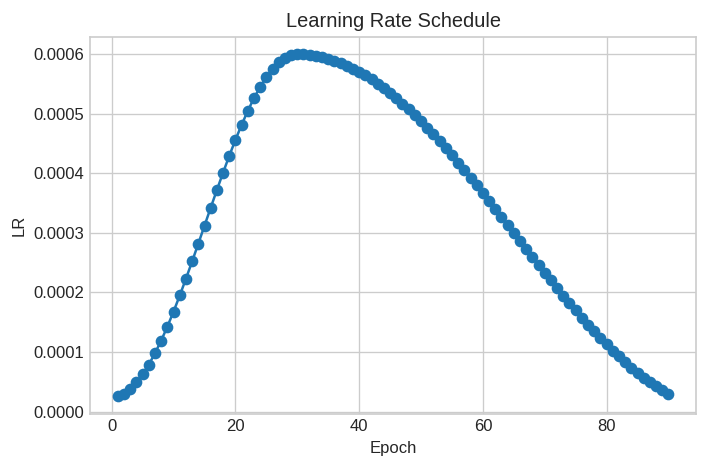

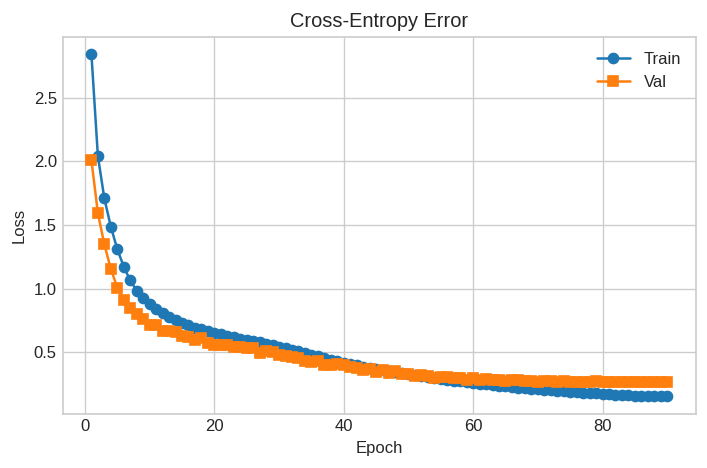

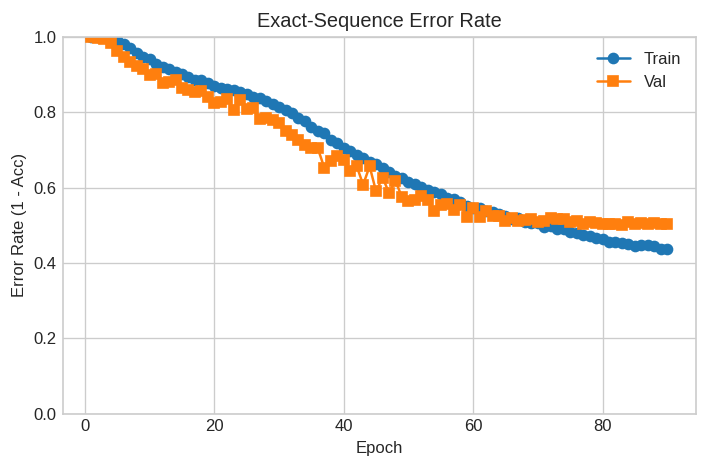

Graphs processed. Note: some metrics might be missing if training was interrupted.


In [28]:
####################################
# paper-ready learning rate and error graphs
####################################
# This cell reads the saved metrics CSV and creates figures suitable for a paper.
if not METRICS_FILE.exists():
    print(f"Metrics file not found yet: {METRICS_FILE}. Run training first.")
else:
    plot_df = pd.read_csv(METRICS_FILE).sort_values("epoch")

    # Map column names based on what's available to prevent KeyErrors
    # We check for common variations used in previous cells
    col_map = {
        "train_seq_acc": "train_sequence_accuracy",
        "val_seq_acc": "validation_sequence_accuracy",
        "train_loss": "train_loss",
        "val_loss": "validation_loss",
        "lr": "learning_rate"
    }

    for target, actual in col_map.items():
        if actual in plot_df.columns and target not in plot_df.columns:
            plot_df[target] = plot_df[actual]

    # Prepare error rates (1 - Accuracy)
    if "train_seq_acc" in plot_df.columns:
        plot_df["train_sequence_error"] = 1.0 - plot_df["train_seq_acc"]
    if "val_seq_acc" in plot_df.columns:
        plot_df["val_sequence_error"] = 1.0 - plot_df["val_seq_acc"]

    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

    # Plot 1: Learning Rate
    if "lr" in plot_df.columns:
        fig1, ax1 = plt.subplots(figsize=(6, 4))
        ax1.plot(plot_df["epoch"], plot_df["lr"], marker="o", color="#1f77b4")
        ax1.set_title("Learning Rate Schedule")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("LR")
        fig1.tight_layout()
        fig1.savefig(RESULTS_DIR / "harakat_lr_debug.png")
        plt.show()

    # Plot 2: Cross-Entropy Loss
    if "train_loss" in plot_df.columns and "val_loss" in plot_df.columns:
        fig2, ax2 = plt.subplots(figsize=(6, 4))
        ax2.plot(plot_df["epoch"], plot_df["train_loss"], marker="o", label="Train")
        ax2.plot(plot_df["epoch"], plot_df["val_loss"], marker="s", label="Val")
        ax2.set_title("Cross-Entropy Error")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Loss")
        ax2.legend()
        fig2.tight_layout()
        fig2.savefig(RESULTS_DIR / "harakat_loss_debug.png")
        plt.show()

    # Plot 3: Sequence Error
    if "train_sequence_error" in plot_df.columns and "val_sequence_error" in plot_df.columns:
        fig3, ax3 = plt.subplots(figsize=(6, 4))
        ax3.plot(plot_df["epoch"], plot_df["train_sequence_error"], marker="o", label="Train")
        ax3.plot(plot_df["epoch"], plot_df["val_sequence_error"], marker="s", label="Val")
        ax3.set_title("Exact-Sequence Error Rate")
        ax3.set_xlabel("Epoch")
        ax3.set_ylabel("Error Rate (1 - Acc)")
        ax3.set_ylim(0, 1)
        ax3.legend()
        fig3.tight_layout()
        fig3.savefig(RESULTS_DIR / "harakat_seq_error_debug.png")
        plt.show()

    print(f"Graphs processed. Note: some metrics might be missing if training was interrupted.")

In [29]:
# Update optimizer and add a scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# OneCycleLR is effective for Transformer training
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE * 2,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS
)

print("Optimizer and Scheduler initialized.")

Optimizer and Scheduler initialized.


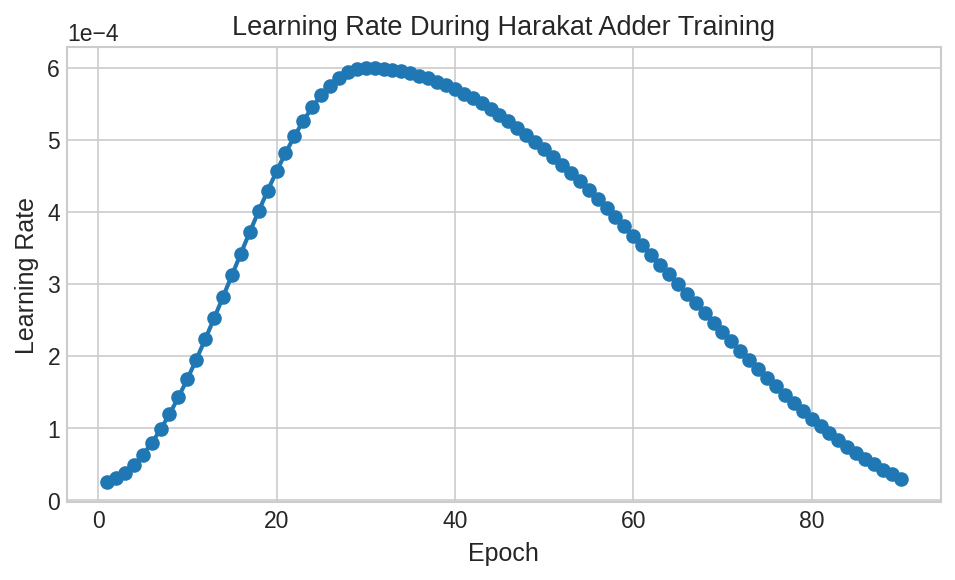

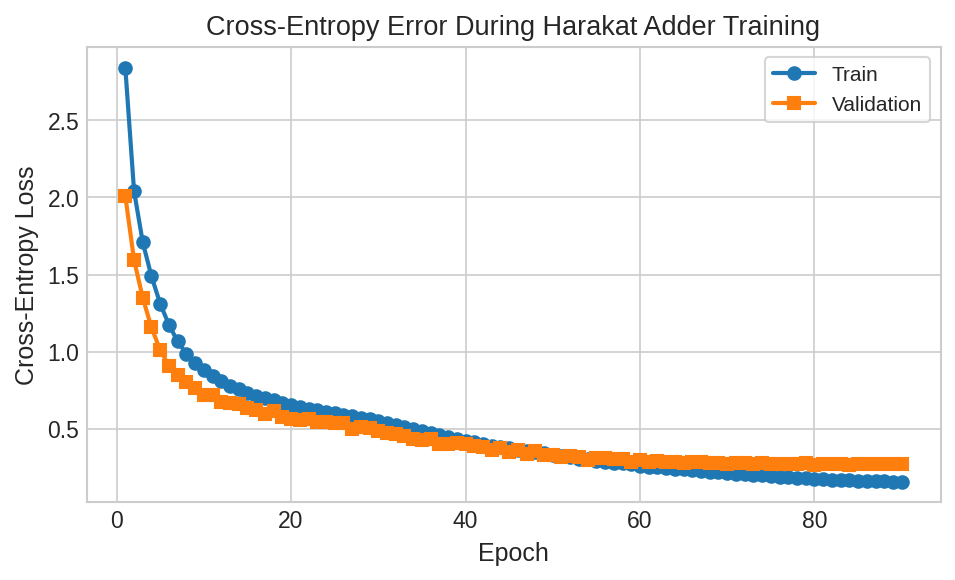

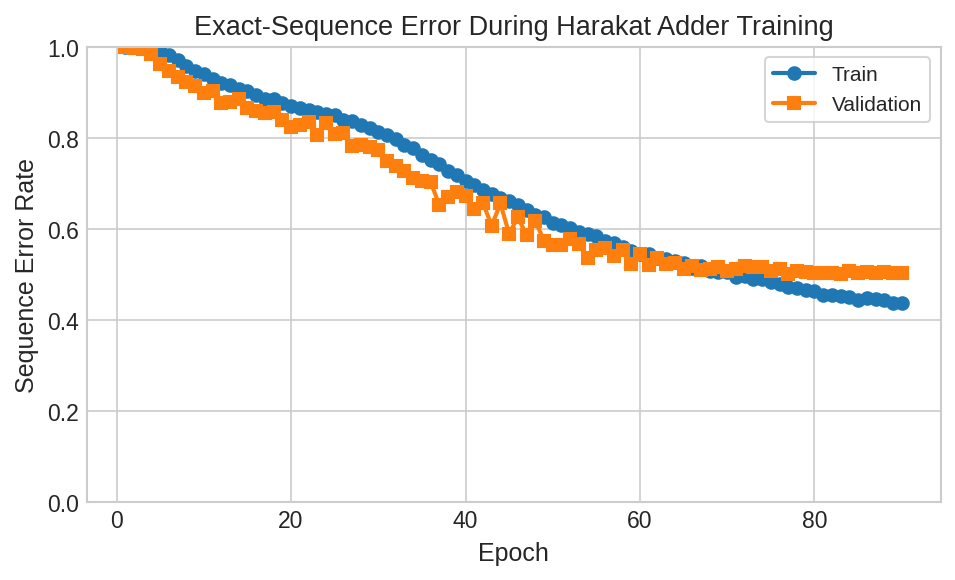

Saved figures to: /content/drive/MyDrive/arabizi
- harakat_learning_rate.png / .pdf
- harakat_loss_error.png / .pdf
- harakat_sequence_error.png / .pdf


In [30]:
####################################
# paper-ready learning rate and error graphs
####################################
# This cell reads the saved metrics CSV and creates figures suitable for a paper.
# It saves both PNG and PDF copies so you can use raster images for quick drafts
# and vector-style PDF output for final submission when the venue allows it.
if not METRICS_FILE.exists():
    raise FileNotFoundError(f"Metrics file not found yet: {METRICS_FILE}")

plot_df = pd.read_csv(METRICS_FILE).sort_values("epoch")
if "learning_rate" not in plot_df.columns:
    plot_df["learning_rate"] = LEARNING_RATE

# Standardize column names to match plotting expectations
# Only rename if original column exists and new name doesn't to avoid overwriting or errors
if "val_seq_acc" in plot_df.columns and "validation_sequence_accuracy" not in plot_df.columns:
    plot_df["validation_sequence_accuracy"] = plot_df["val_seq_acc"]
if "val_loss" in plot_df.columns and "validation_loss" not in plot_df.columns:
    plot_df["validation_loss"] = plot_df["val_loss"]

# Prepare error rates (1 - Accuracy) - only for available metrics
# Add conditional checks for these columns
if "train_sequence_accuracy" in plot_df.columns:
    plot_df["train_sequence_error"] = 1.0 - plot_df["train_sequence_accuracy"]
if "validation_sequence_accuracy" in plot_df.columns:
    plot_df["validation_sequence_error"] = 1.0 - plot_df["validation_sequence_accuracy"]
if "test_sequence_accuracy" in plot_df.columns:
    plot_df["test_sequence_error"] = 1.0 - plot_df["test_sequence_accuracy"]

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
})

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Plot 1: Learning Rate
if "learning_rate" in plot_df.columns:
    fig1, ax1 = plt.subplots(figsize=(6.5, 4.0))
    ax1.plot(plot_df["epoch"], plot_df["learning_rate"], marker="o", linewidth=2.0, color="#1f77b4")
    ax1.set_title("Learning Rate During Harakat Adder Training")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Learning Rate")
    ax1.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    fig1.tight_layout()
    fig1.savefig(RESULTS_DIR / "harakat_learning_rate.png", bbox_inches="tight")
    fig1.savefig(RESULTS_DIR / "harakat_learning_rate.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Learning rate data not available for plotting.")
plt.close('all') # Close all figures after showing to prevent them from staying in memory

# Plot 2: Cross-Entropy Loss
fig2, ax2 = plt.subplots(figsize=(6.5, 4.0))
plotted_loss = False
if "train_loss" in plot_df.columns:
    ax2.plot(plot_df["epoch"], plot_df["train_loss"], marker="o", linewidth=2.0, label="Train")
    plotted_loss = True
if "validation_loss" in plot_df.columns:
    ax2.plot(plot_df["epoch"], plot_df["validation_loss"], marker="s", linewidth=2.0, label="Validation")
    plotted_loss = True
if "test_loss" in plot_df.columns:
    ax2.plot(plot_df["epoch"], plot_df["test_loss"], marker="^", linewidth=2.0, label="Test")
    plotted_loss = True

if plotted_loss:
    ax2.set_title("Cross-Entropy Error During Harakat Adder Training")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Cross-Entropy Loss")
    ax2.legend(frameon=True)
    fig2.tight_layout()
    fig2.savefig(RESULTS_DIR / "harakat_loss_error.png", bbox_inches="tight")
    fig2.savefig(RESULTS_DIR / "harakat_loss_error.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Loss data not available for plotting.")
plt.close('all') # Close all figures after showing to prevent them from staying in memory

# Plot 3: Sequence Error
fig3, ax3 = plt.subplots(figsize=(6.5, 4.0))
plotted_sequence_error = False
if "train_sequence_error" in plot_df.columns:
    ax3.plot(plot_df["epoch"], plot_df["train_sequence_error"], marker="o", linewidth=2.0, label="Train")
    plotted_sequence_error = True
if "validation_sequence_error" in plot_df.columns:
    ax3.plot(plot_df["epoch"], plot_df["validation_sequence_error"], marker="s", linewidth=2.0, label="Validation")
    plotted_sequence_error = True
if "test_sequence_error" in plot_df.columns:
    ax3.plot(plot_df["epoch"], plot_df["test_sequence_error"], marker="^", linewidth=2.0, label="Test")
    plotted_sequence_error = True

if plotted_sequence_error:
    ax3.set_title("Exact-Sequence Error During Harakat Adder Training")
    ax3.set_xlabel("Epoch")
    ax3.set_ylabel("Sequence Error Rate")
    ax3.set_ylim(0.0, 1.0)
    ax3.legend(frameon=True)
    fig3.tight_layout()
    fig3.savefig(RESULTS_DIR / "harakat_sequence_error.png", bbox_inches="tight")
    fig3.savefig(RESULTS_DIR / "harakat_sequence_error.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Sequence error data not available for plotting.")
plt.close('all') # Close all figures after showing to prevent them from staying in memory


print("Saved figures to:", RESULTS_DIR)
print("- harakat_learning_rate.png / .pdf")
print("- harakat_loss_error.png / .pdf")
print("- harakat_sequence_error.png / .pdf")